4. Hashtag popularity analysis: Determine which hashtags are most popular among different user groups.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

In [4]:
df = pd.read_csv('CSV/location.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
tags =  []
for text in df['Hashtags']:
    tags.extend(re.findall(r'#[a-z|A-Z]*', text))
print(tags)

['#Nature', '#Park', '#Traffic', '#Morning', '#Fitness', '#Workout', '#Travel', '#Adventure', '#Cooking', '#Food', '#Gratitude', '#PositiveVibes', '#RainyDays', '#Cozy', '#MovieNight', '#MustWatch', '#Politics', '#Debate', '#Summer', '#BeachDays', '#Blogging', '#NewPost', '#SickDay', '#Health', '#CityExplore', '#HiddenGems', '#NewYear', '#FitnessGoals', '#Tech', '#Innovation', '#Reflection', '#Future', '#PetAdoption', '#FurryFriend', '#Gaming', '#LateNight', '#AI', '#TechConference', '#WinterBlues', '#Mood', '#Reading', '#CoffeeTime', '#VR', '#VirtualReality', '#Productivity', '#WorkFromHome', '#Fitness', '#ChallengeAccepted', '#Career', '#Milestone', '#Brunch', '#Friends', '#LanguageLearning', '#PersonalGrowth', '#Reading', '#QuietTime', '#MentalHealth', '#SelfCare', '#Art', '#PaintingInProgress', '#RoadTrip', '#ScenicViews', '#TeaTime', '#Sunset', '#Coding', '#Enthusiasm', '#Inspiration', '#Workshop', '#WinterSports', '#Fun', '#FamilyTime', '#Weekend', '#Music', '#ConcertNight', '#Mi

In [7]:
counts = []
elements = []
for x in element_count:
    counts.append(element_count.get(x))
    elements.append(x)

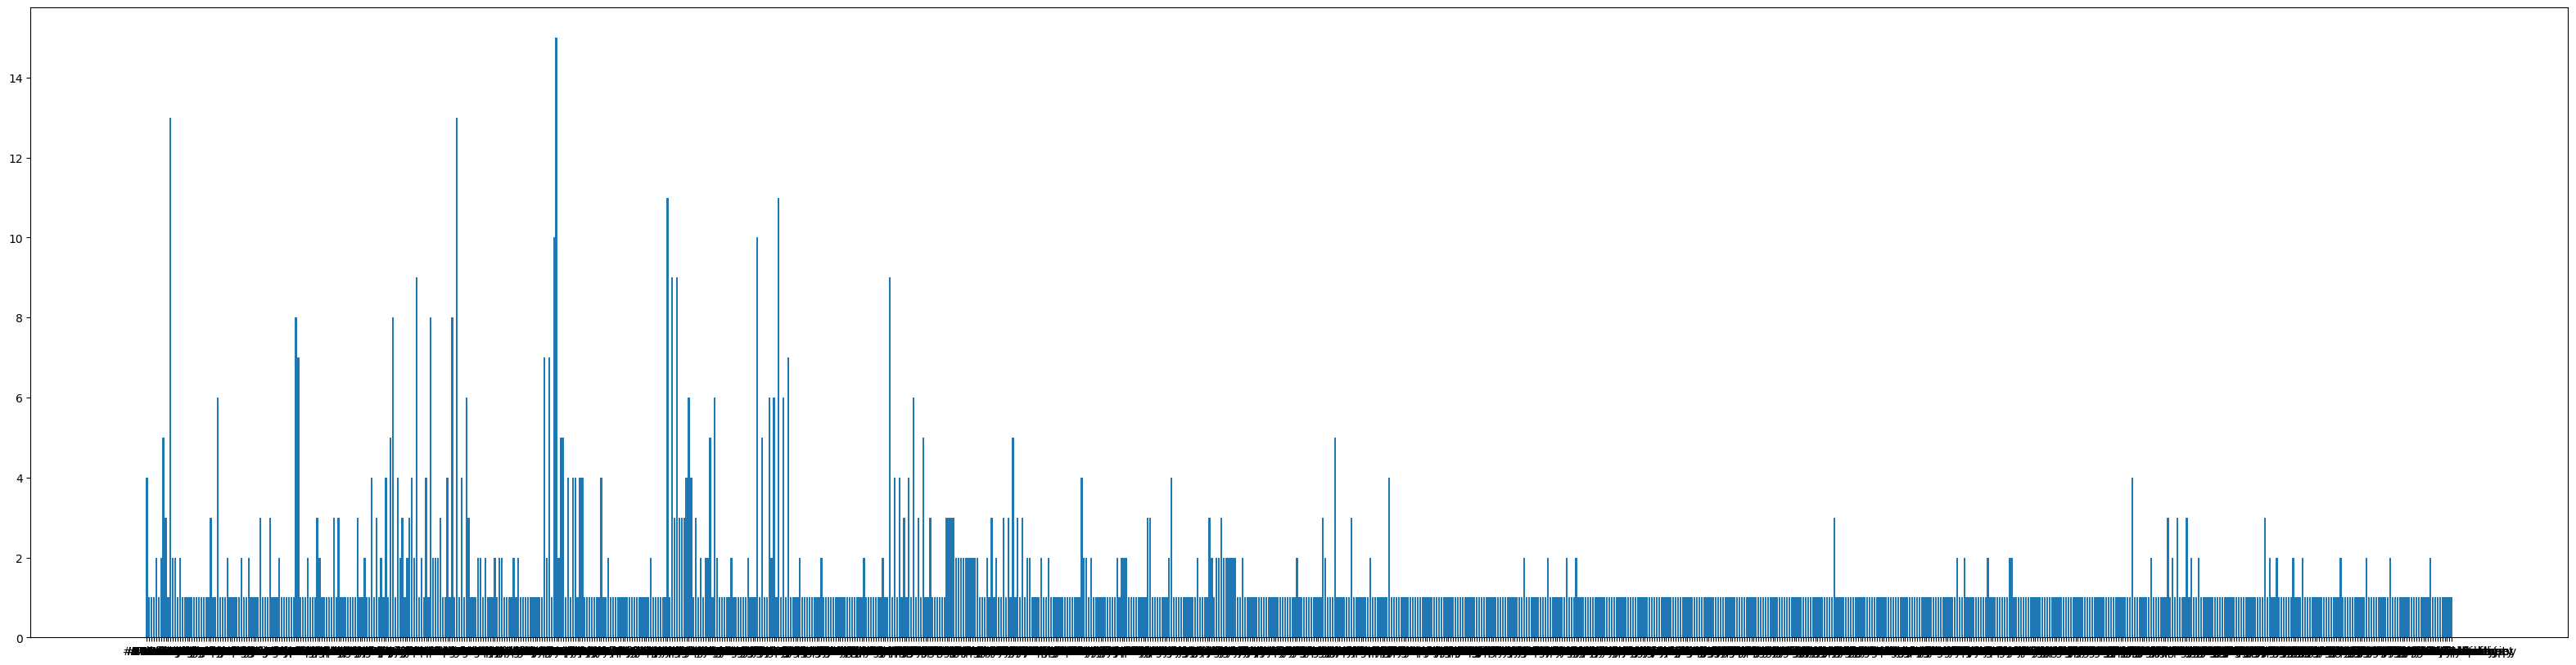

In [8]:
plt.figure(figsize=(40,10))
plt.bar(elements, counts)
plt.show()

In [9]:
# long method

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
import numpy as np

In [11]:
def extract_hashtags(text):
  return ' '.join([word for word in text.split() if word.startswith("#")])

In [12]:
df['hashtags_split'] = df['Hashtags'].apply(extract_hashtags)
print(df.head())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes     

In [14]:
vectorizer = CountVectorizer()
hashtag_matrix = vectorizer.fit_transform(df['Hashtags'])

In [15]:
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(hashtag_matrix)

In [16]:
print(df[['Hashtags', 'cluster']])

                                          Hashtags  cluster
0        #Nature #Park                                    0
1        #Traffic #Morning                                0
2        #Fitness #Workout                                0
3        #Travel #Adventure                               0
4        #Cooking #Food                                   0
..                                             ...      ...
727         #ScienceFairWinner #HighSchoolScience         0
728    #SurpriseCelebration #HighSchoolFriendship         0
729      #CommunityGiving #HighSchoolPhilanthropy         0
730         #CulturalCelebration #HighSchoolUnity         0
731   #VirtualEntertainment #HighSchoolPositivity         0

[732 rows x 2 columns]


In [17]:
for cluster_num in range(num_clusters):
  cluster_hashtags = []
  cluster_data = df[df['cluster'] == cluster_num]['hashtags_split']
  for text in cluster_data:
    cluster_hashtags = []
    cluster_hashtags.extend(text.split())
  unique_hashtags = np.unique(cluster_hashtags)
  print(f"Cluster {cluster_num} Hashtags: {unique_hashtags}")

Cluster 0 Hashtags: ['#HighSchoolPositivity' '#VirtualEntertainment']
Cluster 1 Hashtags: ['#Desolation' '#UntoldSorrows']
Cluster 2 Hashtags: ['#EdSheeranConcert' '#Serenity']
Cluster 3 Hashtags: ['#CrashingWaves' '#Loneliness']
Cluster 4 Hashtags: ['#Innovation' '#Tech']
